<a href="https://www.kaggle.com/code/sonawanelalitsunil/post-covid-conditions-eda-ml-99-42?scriptVersionId=266230607" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/post-covid-conditions-dataset/Post-COVID_Conditions.csv


## Title: Post-COVID Conditions Dataset

## Description:
This dataset contains detailed information on individuals experiencing post-COVID conditions, often referred to as “long COVID.” It includes demographic, clinical, and lifestyle variables such as age, gender, pre-existing health conditions, symptom duration, severity, treatment methods, recovery timelines, and quality of life indicators. The dataset can be used for analyzing risk factors, identifying symptom patterns, predicting long-term health outcomes, and developing data-driven healthcare strategies for post-COVID management.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/post-covid-conditions-dataset/Post-COVID_Conditions.csv")

In [3]:
df.head()

,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,LowCI,HighCI,Confidence Interval,Quartile range,Quartile number,Suppression Flag
0,"Ever experienced long COVID, as a percentage o...",National Estimate,United States,United States,3.5,46,"Jun 1 - Jun 13, 2022",06/01/2022,06/13/2022,14.0,13.5,14.5,13.5 - 14.5,NaN,NaN,NaN
1,"Ever experienced long COVID, as a percentage o...",By Age,United States,18 - 29 years,3.5,46,"Jun 1 - Jun 13, 2022",06/01/2022,06/13/2022,17.8,15.9,19.8,15.9 - 19.8,NaN,NaN,NaN
2,"Ever experienced long COVID, as a percentage o...",By Age,United States,30 - 39 years,3.5,46,"Jun 1 - Jun 13, 2022",06/01/2022,06/13/2022,15.2,14.1,16.2,14.1 - 16.2,NaN,NaN,NaN
3,"Ever experienced long COVID, as a percentage o...",By Age,United States,40 - 49 years,3.5,46,"Jun 1 - Jun 13, 2022",06/01/2022,06/13/2022,16.9,15.7,18.3,15.7 - 18.3,NaN,NaN,NaN
4,"Ever experienced long COVID, as a percentage o...",By Age,United States,50 - 59 years,3.5,46,"Jun 1 - Jun 13, 2022",06/01/2022,06/13/2022,15.3,14.1,16.7,14.1 - 16.7,NaN,NaN,NaN


In [4]:
df.tail()

,Indicator,Group,State,Subgroup,Phase,Time Period,Time Period Label,Time Period Start Date,Time Period End Date,Value,LowCI,HighCI,Confidence Interval,Quartile range,Quartile number,Suppression Flag
18634,Significant activity limitations from long COV...,By State,Virginia,Virginia,4.2,72,"Aug 20 - Sep 16, 2024",08/20/2024,09/16/2024,1.0,0.4,2.0,0.4 - 2.0,1.0-1.3,2.0,NaN
18635,Significant activity limitations from long COV...,By State,Washington,Washington,4.2,72,"Aug 20 - Sep 16, 2024",08/20/2024,09/16/2024,1.1,0.6,1.7,0.6 - 1.7,1.0-1.3,2.0,NaN
18636,Significant activity limitations from long COV...,By State,West Virginia,West Virginia,4.2,72,"Aug 20 - Sep 16, 2024",08/20/2024,09/16/2024,1.1,0.4,2.4,0.4 - 2.4,1.0-1.3,2.0,NaN
18637,Significant activity limitations from long COV...,By State,Wisconsin,Wisconsin,4.2,72,"Aug 20 - Sep 16, 2024",08/20/2024,09/16/2024,1.5,0.7,2.9,0.7 - 2.9,1.4-1.6,3.0,NaN
18638,Significant activity limitations from long COV...,By State,Wyoming,Wyoming,4.2,72,"Aug 20 - Sep 16, 2024",08/20/2024,09/16/2024,NaN,NaN,NaN,NaN,Estimate not reliable,-1.0,1.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18639 entries, 0 to 18638
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Indicator               18639 non-null  object 
 1   Group                   18639 non-null  object 
 2   State                   18639 non-null  object 
 3   Subgroup                18639 non-null  object 
 4   Phase                   18639 non-null  float64
 5   Time Period             18639 non-null  int64  
 6   Time Period Label       18639 non-null  object 
 7   Time Period Start Date  18639 non-null  object 
 8   Time Period End Date    18639 non-null  object 
 9   Value                   16186 non-null  float64
 10  LowCI                   16186 non-null  float64
 11  HighCI                  16186 non-null  float64
 12  Confidence Interval     16186 non-null  object 
 13  Quartile range          11780 non-null  object 
 14  Quartile number         11777 non-null

In [6]:
df.describe()

,Phase,Time Period,Value,LowCI,HighCI,Quartile number,Suppression Flag
count,18639.000000,18639.000000,16186.000000,16186.000000,16186.000000,11777.000000,1832.0
mean,3.617479,57.670208,22.978111,19.675516,26.588855,1.961620,1.0
std,0.912296,12.835375,22.475114,20.853023,23.909894,1.553579,0.0
min,-1.000000,1.000000,0.000000,0.000000,0.500000,-1.000000,1.0
25%,3.600000,53.000000,5.900000,4.400000,7.700000,1.000000,1.0
50%,3.800000,59.000000,14.700000,11.400000,18.100000,2.000000,1.0
75%,4.000000,66.000000,31.300000,26.500000,38.300000,3.000000,1.0
max,4.200000,72.000000,92.800000,90.300000,95.400000,4.000000,1.0


In [7]:
df.nunique()

Indicator                     9
Group                         9
State                        52
Subgroup                     78
Phase                        10
Time Period                  28
Time Period Label            30
Time Period Start Date       30
Time Period End Date         30
Value                       891
LowCI                       844
HighCI                      915
Confidence Interval       12038
Quartile range              854
Quartile number               5
Suppression Flag              1
dtype: int64

In [8]:
df.isnull().sum()

Indicator                     0
Group                         0
State                         0
Subgroup                      0
Phase                         0
Time Period                   0
Time Period Label             0
Time Period Start Date        0
Time Period End Date          0
Value                      2453
LowCI                      2453
HighCI                     2453
Confidence Interval        2453
Quartile range             6859
Quartile number            6862
Suppression Flag          16807
dtype: int64

In [9]:
df.duplicated().sum()

1

In [10]:
df.describe().loc[['min','max','mean']]

,Phase,Time Period,Value,LowCI,HighCI,Quartile number,Suppression Flag
min,-1.000000,1.000000,0.000000,0.000000,0.500000,-1.00000,1.0
max,4.200000,72.000000,92.800000,90.300000,95.400000,4.00000,1.0
mean,3.617479,57.670208,22.978111,19.675516,26.588855,1.96162,1.0


In [11]:
df.dtypes

Indicator                  object
Group                      object
State                      object
Subgroup                   object
Phase                     float64
Time Period                 int64
Time Period Label          object
Time Period Start Date     object
Time Period End Date       object
Value                     float64
LowCI                     float64
HighCI                    float64
Confidence Interval        object
Quartile range             object
Quartile number           float64
Suppression Flag          float64
dtype: object

In [12]:
df.shape

(18639, 16)

In [13]:
df.columns

Index(['Indicator', 'Group', 'State', 'Subgroup', 'Phase', 'Time Period',
       'Time Period Label', 'Time Period Start Date', 'Time Period End Date',
       'Value', 'LowCI', 'HighCI', 'Confidence Interval', 'Quartile range',
       'Quartile number', 'Suppression Flag'],
      dtype='object')

## Data visualizations

In [14]:
print("Dataset shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values per column:\n", df.isnull().sum())

Dataset shape: (18639, 16)

Columns:
 Index(['Indicator', 'Group', 'State', 'Subgroup', 'Phase', 'Time Period',
       'Time Period Label', 'Time Period Start Date', 'Time Period End Date',
       'Value', 'LowCI', 'HighCI', 'Confidence Interval', 'Quartile range',
       'Quartile number', 'Suppression Flag'],
      dtype='object')

Missing values per column:
 Indicator                     0
Group                         0
State                         0
Subgroup                      0
Phase                         0
Time Period                   0
Time Period Label             0
Time Period Start Date        0
Time Period End Date          0
Value                      2453
LowCI                      2453
HighCI                     2453
Confidence Interval        2453
Quartile range             6859
Quartile number            6862
Suppression Flag          16807
dtype: int64


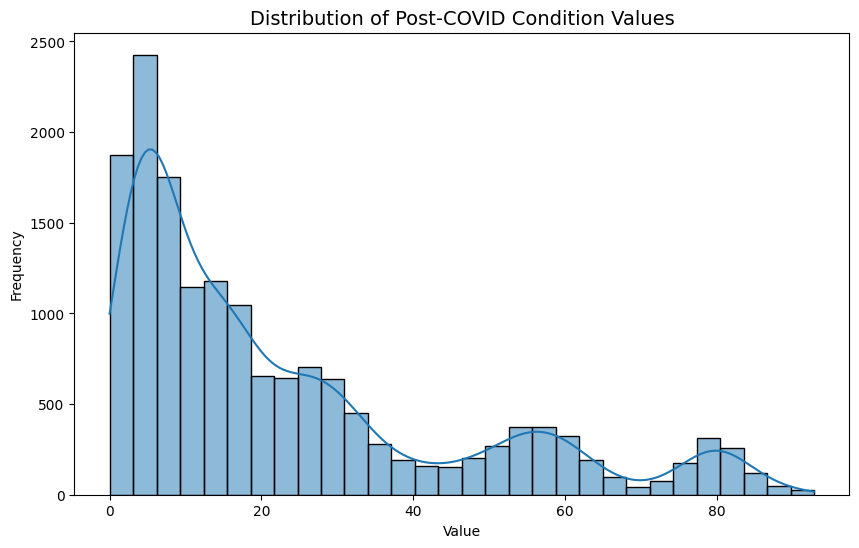

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df['Value'], bins=30, kde=True)
plt.title("Distribution of Post-COVID Condition Values", fontsize=14)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

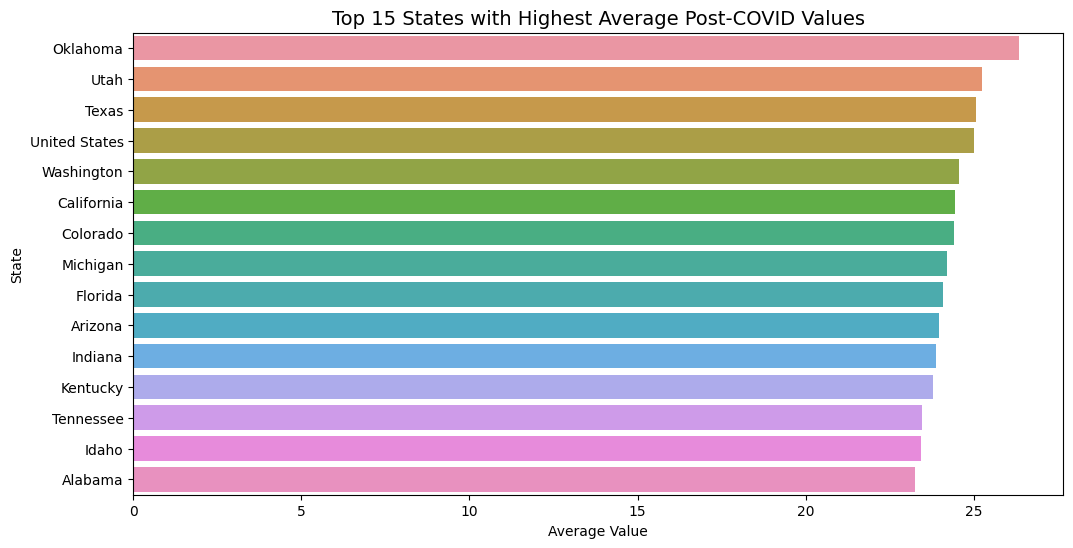

In [16]:
state_avg = df.groupby('State')['Value'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(12,6))
sns.barplot(x=state_avg.values, y=state_avg.index)
plt.title("Top 15 States with Highest Average Post-COVID Values", fontsize=14)
plt.xlabel("Average Value")
plt.ylabel("State")
plt.show()


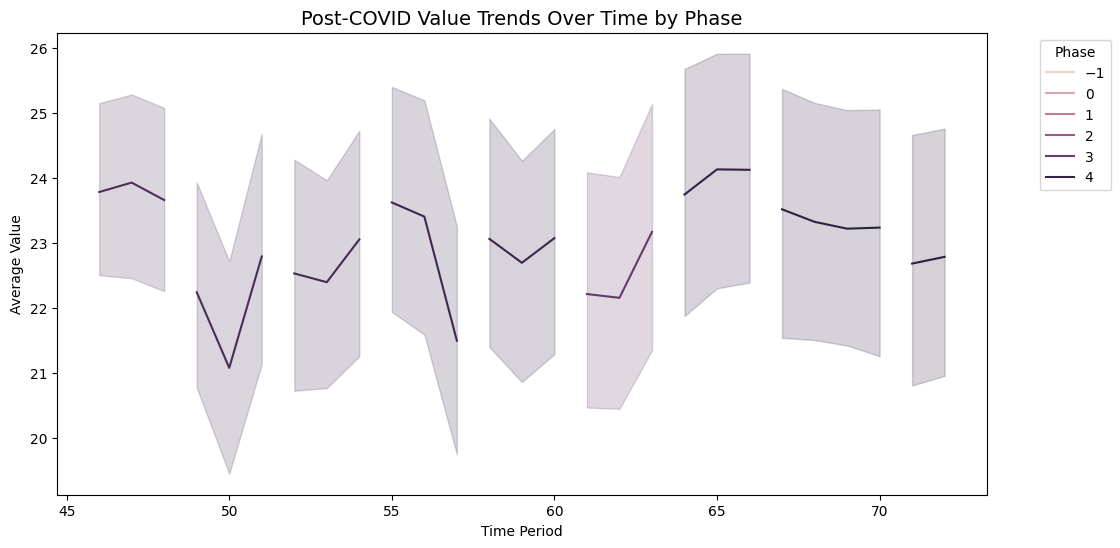

In [17]:
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Time Period', y='Value', hue='Phase', estimator='mean')
plt.title("Post-COVID Value Trends Over Time by Phase", fontsize=14)
plt.xlabel("Time Period")
plt.ylabel("Average Value")
plt.legend(title='Phase', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


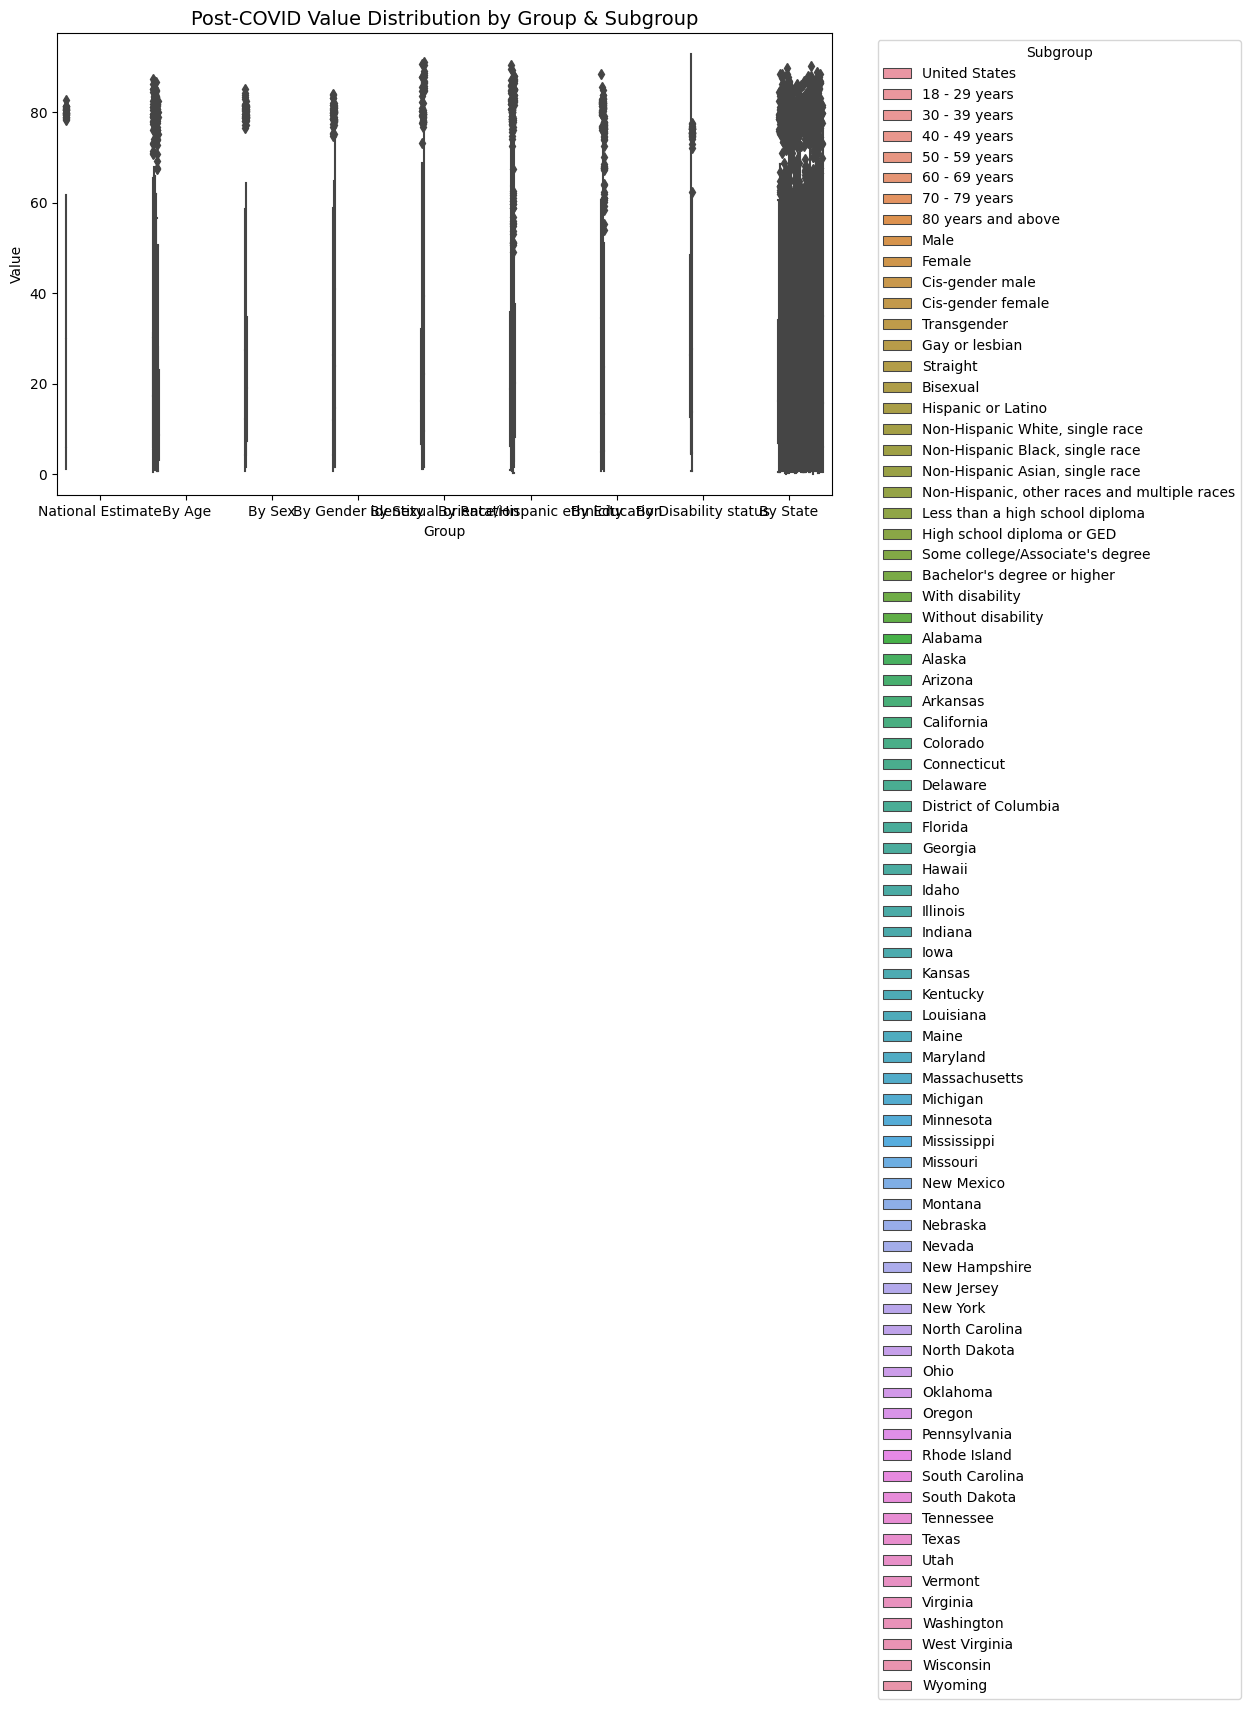

In [18]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Group', y='Value', hue='Subgroup')
plt.title("Post-COVID Value Distribution by Group & Subgroup", fontsize=14)
plt.xlabel("Group")
plt.ylabel("Value")
plt.legend(title='Subgroup', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


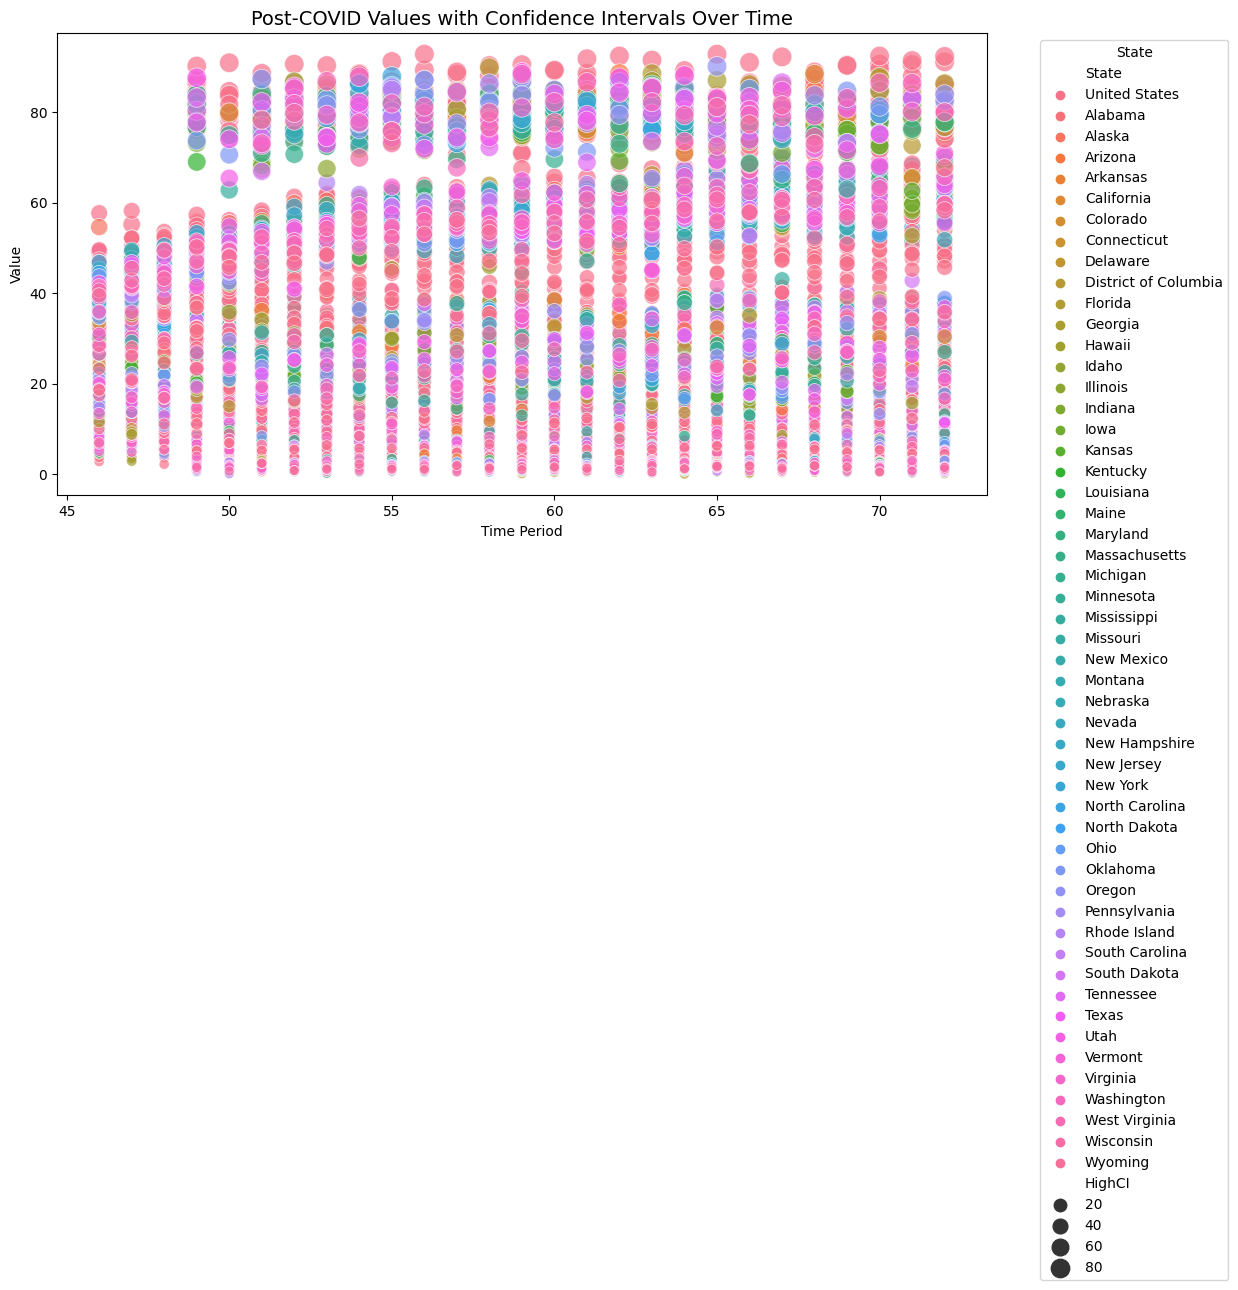

In [19]:
plt.figure(figsize=(12,6))
sns.scatterplot(data=df, x='Time Period', y='Value', hue='State', size='HighCI', sizes=(50,200), alpha=0.7)
plt.title("Post-COVID Values with Confidence Intervals Over Time", fontsize=14)
plt.xlabel("Time Period")
plt.ylabel("Value")
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


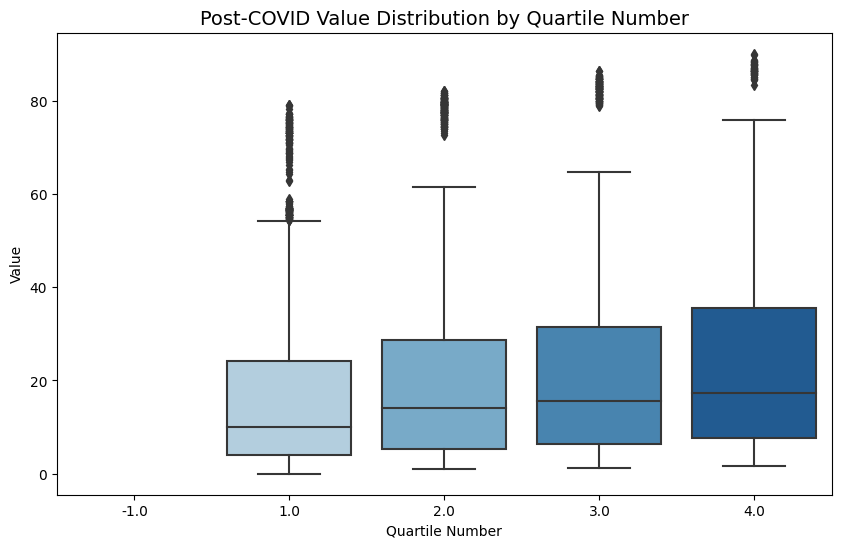

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Quartile number', y='Value', palette="Blues")
plt.title("Post-COVID Value Distribution by Quartile Number", fontsize=14)
plt.xlabel("Quartile Number")
plt.ylabel("Value")
plt.show()

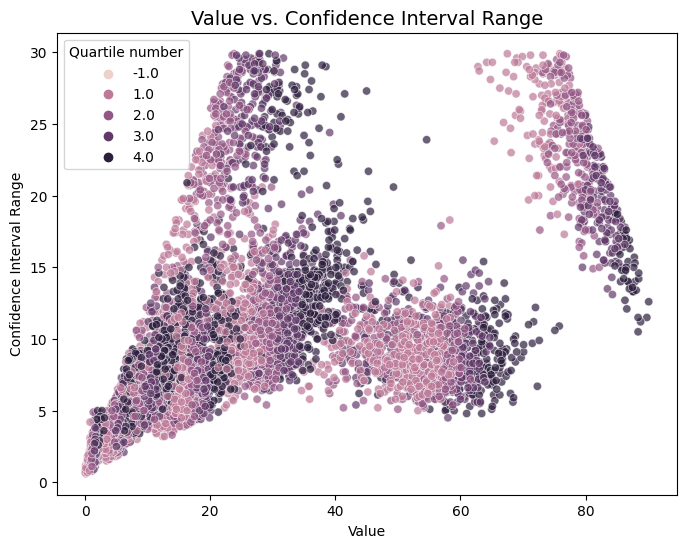

In [21]:
df['CI_range'] = df['HighCI'] - df['LowCI']
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Value', y='CI_range', hue='Quartile number', alpha=0.7)
plt.title("Value vs. Confidence Interval Range", fontsize=14)
plt.xlabel("Value")
plt.ylabel("Confidence Interval Range")
plt.show()

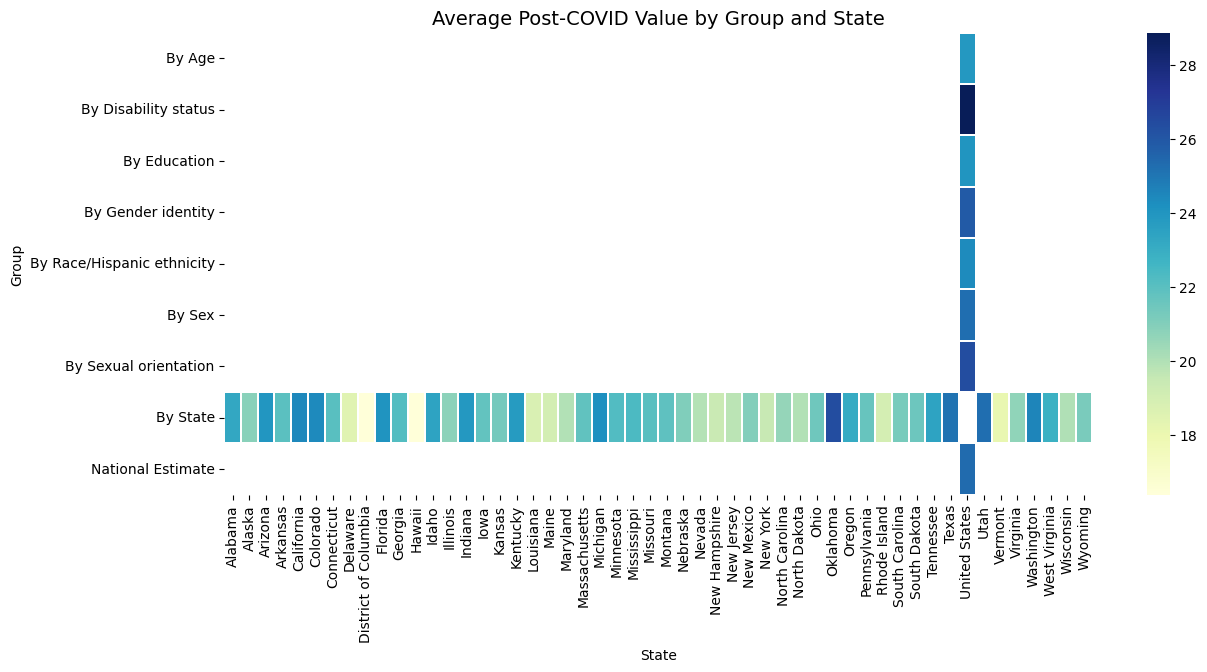

In [22]:
pivot_table = df.pivot_table(values='Value', index='Group', columns='State', aggfunc='mean')
plt.figure(figsize=(14,6))
sns.heatmap(pivot_table, cmap="YlGnBu", linewidths=0.3)
plt.title("Average Post-COVID Value by Group and State", fontsize=14)
plt.xlabel("State")
plt.ylabel("Group")
plt.show()

## ML Algorithms

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [24]:
label_enc = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = label_enc.fit_transform(df[col].astype(str))


In [25]:
imputer = SimpleImputer(strategy='median')
df[:] = imputer.fit_transform(df)

In [26]:
X = df.drop(columns=['Quartile number'])   # Predicting quartile category
y = df['Quartile number']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (14911, 16)
Test shape: (3728, 16)


In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC()
}

In [29]:
accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds) * 100
    accuracy_results[name] = round(acc, 2)
    print(f"{name}: {acc:.2f}%")

Logistic Regression: 55.82%
Decision Tree: 99.41%
Random Forest: 98.85%
Gradient Boosting: 92.06%
K-Nearest Neighbors: 77.39%
Support Vector Machine: 53.76%


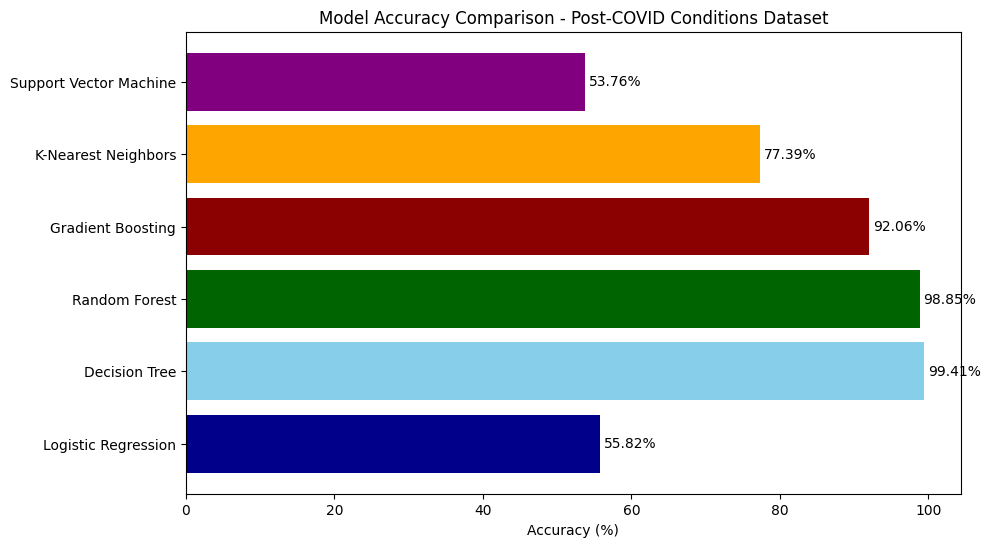

In [30]:
plt.figure(figsize=(10,6))
plt.barh(list(accuracy_results.keys()), list(accuracy_results.values()), color=['darkblue', 'skyblue', 'darkgreen', 'darkred', 'orange', 'purple'])
plt.xlabel("Accuracy (%)")
plt.title("Model Accuracy Comparison - Post-COVID Conditions Dataset")
for i, v in enumerate(accuracy_results.values()):
    plt.text(v + 0.5, i, f"{v}%", va='center', fontsize=10)
plt.show()

In [31]:
best_model = max(accuracy_results, key=accuracy_results.get)
print(f"\n🏆 Best Performing Model: {best_model} ({accuracy_results[best_model]}% Accuracy)")


🏆 Best Performing Model: Decision Tree (99.41% Accuracy)


## Thank you...pls upvote!!!!